# Defenseman D-Zone Exit Metrics, 2025-26 (all teams)

For every defenseman shift where the puck was in his team's defensive zone:
* **Avg. time to clear** - how long until the puck is out (shifts where he gets it out)
* **% of D-zone shifts w/o a clearance** - D-zone shifts with no observed exit

Shifts that never touch the D-zone count in neither number. A player traded mid-season appears on **both** teams' charts, each dot built only from his games with that team (marked `*`).

Data: NHL `api-web` play-by-play + `shiftcharts` (cached to `./nhl_cache`). Method notes are in the module docstring of `NHL_DMan_Shift_Processor.py`.

In [1]:
import NHL_DMan_Shift_Processor_v2 as dsp

SEASON    = 20252026   # 2025-26
MIN_GAMES = 10         # games WITH THAT TEAM needed for a (team, player) dot to appear
TEAM      = "LAK"      # team for the single-team chart below
params    = dsp.ZoneParams(carryover_seconds=5, interpolate=True)

In [2]:
# First run pulls ~1,300 games x 2 feeds (expect 10-20 min). Everything is cached in ./nhl_cache,
# so re-runs (and re-tuning `params`) take seconds and need no network.
shifts = dsp.build_shift_table(season=SEASON, params=params, max_workers=6)
shifts.to_csv(f"dman_shifts_{SEASON}.csv", index=False)
shifts.attrs["failed_games"]   # anything listed here: re-run this cell to retry just those games

1312 completed regular-season games for 2025-26
  processed 100/1312 games (0 failed)
  processed 200/1312 games (0 failed)
  processed 300/1312 games (0 failed)
  processed 400/1312 games (0 failed)
  processed 500/1312 games (0 failed)
  processed 600/1312 games (0 failed)
  processed 700/1312 games (0 failed)
  processed 800/1312 games (0 failed)
  processed 900/1312 games (0 failed)
  processed 1000/1312 games (0 failed)
  processed 1100/1312 games (0 failed)
  processed 1200/1312 games (0 failed)
  processed 1300/1312 games (0 failed)
  processed 1312/1312 games (0 failed)


[]

### Sanity checks (worth a glance on the first run)
`outcome` per defenseman shift: `none` = never in the D-zone, `exit` = observed clear, `whistle` = D-zone time ended by a stoppage (icing, goal against, etc.), `open` = shift ended with the puck last seen in the D-zone.
The zone-convention table should show ~100 in `owner_pct` for every event type except `blocked-shot`, which should be ~100 in `other_pct`.

In [3]:
print(f"{shifts.game_id.nunique()} games | {shifts.player_id.nunique()} defensemen | {len(shifts):,} shifts")
print(shifts.outcome.value_counts(normalize=True).round(3).to_string())

client = dsp.NHLClient()
games  = client.season_games(SEASON)
dsp.check_zone_conventions(client.play_by_play(int(games.game_id.iloc[0])))

1312 games | 325 defensemen | 373,693 shifts
outcome
open       0.430
none       0.320
exit       0.224
whistle    0.027


,n,owner_pct,other_pct
event,,,
blocked-shot,31,0.0,100.0
faceoff,50,100.0,0.0
giveaway,26,100.0,0.0
goal,5,100.0,0.0
hit,50,100.0,0.0
missed-shot,26,100.0,0.0
penalty,3,100.0,0.0
shot-on-goal,50,100.0,0.0
takeaway,5,100.0,0.0


In [4]:
summary = dsp.summarize(shifts, min_games=MIN_GAMES, time_basis="exit")   # time_basis="all" = original avg-shift-D-zone-time definition
summary.head(10)

,team,player,player_id,multi_team,gp,first_game,last_game,shifts,dz_shifts,exit_shifts,whistle_shifts,open_shifts,avg_time_s,time_n,no_exit_pct,avg_exit_seconds,avg_dzone_seconds
0,ANA,Drew Helleson,8481563,False,60,2025-10-09,2026-04-14,1387,943,296,47,600,13.814189,296,68.610817,13.814189,22.277306
1,ANA,Ian Moore,8482178,False,67,2025-10-19,2026-04-16,1316,843,287,38,518,14.092334,287,65.954923,14.092334,21.247924
2,ANA,Jackson LaCombe,8481605,False,82,2025-10-09,2026-04-16,2247,1511,560,82,869,17.366964,560,62.938451,17.366964,24.858703
3,ANA,Jacob Trouba,8476885,False,81,2025-10-09,2026-04-16,2280,1583,547,69,967,15.842779,547,65.445357,15.842779,25.880922
4,ANA,John Carlson,8474590,True,16,2026-03-15,2026-04-16,446,295,87,14,194,15.321839,87,70.508475,15.321839,22.883051
5,ANA,Olen Zellweger,8482803,False,76,2025-10-09,2026-04-07,1667,1092,395,41,656,15.678481,395,63.827839,15.678481,22.122711
6,ANA,Pavel Mintyukov,8483490,False,73,2025-10-09,2026-04-16,1792,1199,384,53,762,14.445312,384,67.973311,14.445312,23.772310
7,ANA,Radko Gudas,8475462,False,56,2025-10-09,2026-04-12,1177,815,272,30,513,16.218750,272,66.625767,16.218750,24.300613
8,BOS,Andrew Peeke,8479369,False,77,2025-10-08,2026-04-14,1870,1354,456,41,857,14.835526,456,66.322009,14.835526,25.793575
9,BOS,Charlie McAvoy,8479325,False,69,2025-10-08,2026-04-14,1872,1355,463,53,839,16.718143,463,65.830258,16.718143,26.632472


### Players who changed teams
Each team's row uses only that team's games; check that the date ranges line up with the actual trade.

In [5]:
dsp.traded_players(summary)

,player,team,gp,first_game,last_game,dz_shifts,avg_time_s,no_exit_pct
0,Brett Kulak,EDM,31,2025-10-08,2025-12-11,451,17.017606,68.514412
1,Brett Kulak,PIT,25,2025-12-16,2026-02-05,377,20.605072,63.395225
2,Brett Kulak,COL,27,2026-02-25,2026-04-16,411,16.735669,61.800487
3,Carson Soucy,NYR,46,2025-10-07,2026-01-23,755,15.844444,70.198675
4,Carson Soucy,NYI,30,2026-01-28,2026-04-14,425,12.587963,74.588235
5,Connor Murphy,CHI,60,2025-10-07,2026-03-01,885,17.450758,70.169492
6,Connor Murphy,EDM,20,2026-03-06,2026-04-16,384,15.504762,72.656250
7,David Jiricek,MIN,25,2025-10-09,2026-01-31,253,15.632353,59.683794
8,Donovan Sebrango,FLA,40,2025-11-01,2026-04-15,520,14.603659,68.461538
9,Egor Zamula,PHI,13,2025-10-09,2025-12-07,168,13.576087,72.619048


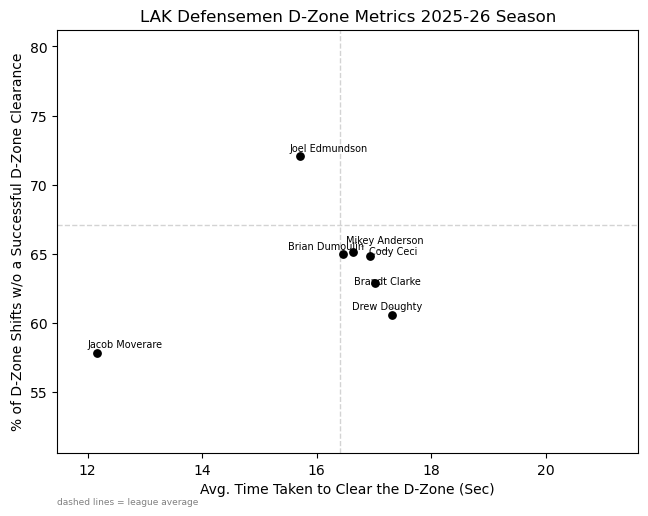

Name              GP    D-zone shifts    Avg. Time to Clear (Sec)    % D-Zone Shifts w/o a Clearance
Jacob Moverare    15              121                       12.17                               57.9
Drew Doughty      72             1264                       17.31                               60.6
Brandt Clarke     82             1233                       17.02                               62.9
Cody Ceci         82             1244                       16.93                               64.9
Brian Dumoulin    82             1227                       16.45                               65
Mikey Anderson    80             1378                       16.63                               65.1
Joel Edmundson    82             1369                       15.71                               72.1


In [6]:
print(dsp.build_team_chart(summary, TEAM))

In [7]:
paths = dsp.plot_all_teams(summary, save_dir="charts")   # one PNG per team, shared axes
print(f"saved {len(paths)} charts to ./charts")

saved 32 charts to ./charts
